In [2]:
!pip install kagglehub matplotlib scikit-learn opencv-python segmentation-models numpy==1.26.4
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/beginner-chest-xray-image-classification")

print("Path to dataset files:", path)

  Obtaining dependency information for kagglehub from https://files.pythonhosted.org/packages/d4/0b/696bf3479afa593493be4a30416263e3a0677479306e8d7088fd95729987/kagglehub-0.4.0-py3-none-any.whl.metadata
  Using cached kagglehub-0.4.0-py3-none-any.whl.metadata (38 kB)
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/36/4d/4a67f30778a45d542bbea5db2dbfa1e9e100bf9ba64aefe34215ba9f11f6/scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached scikit_learn-1.8.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Obtaining dependency information for opencv-python from https://files.pythonhosted.org/packages/68/1f/795e7f4aa2eacc59afa4fb61a2e35e510d06414dd5a802b51a012d691b37/opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
 

100%|██████████| 2.08G/2.08G [00:39<00:00, 56.7MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/vivek468/beginner-chest-xray-image-classification/versions/1


In [3]:
from PIL import Image
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf
import os
import numpy as np
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dropout, MaxPooling2D, Flatten, Dense
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-01-15 09:22:40.025009: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-15 09:22:40.085239: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-15 09:22:40.085295: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-15 09:22:40.085353: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-15 09:22:40.100161: I tensorflow/core/platform/cpu_feature_g

In [4]:
train_dir = '/root/.cache/kagglehub/datasets/vivek468/beginner-chest-xray-image-classification/versions/1/chest_xray/train'
test_dir  = '/root/.cache/kagglehub/datasets/vivek468/beginner-chest-xray-image-classification/versions/1/chest_xray/test'

In [6]:
train_datagen = ImageDataGenerator(               
    rescale=1./255,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=(0.95, 1.05),
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

#Splitting The Train and Test Data

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

Found 7315 images belonging to 2 classes.
Found 620 images belonging to 2 classes.


In [7]:
import os

#Setting The Environment as per Required

os.environ["SM_FRAMEWORK"] = "tf.keras"

import segmentation_models as sm

#For Unet Backbone Will be Used The Famous Resnet-34. Mostly Used in Medical Imaging

BACKBONE = 'resnet34'
preprocess_input = sm.get_preprocessing(BACKBONE)

Segmentation Models: using `tf.keras` framework.


In [8]:
import tensorflow as tf

def softmax_dice_loss(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # get number of dims
    axes = list(range(len(y_true.shape)-1))  

    intersection = tf.reduce_sum(y_true * y_pred, axis=axes)
    union = tf.reduce_sum(y_true + y_pred, axis=axes)

    dice = (2. * intersection + smooth) / (union + smooth)

    return 1 - tf.reduce_mean(dice)

In [15]:
import os
os.environ["SM_FRAMEWORK"] = "tf.keras"
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,BatchNormalization,Dropout
import segmentation_models as sm

conv_base = sm.Unet(
    backbone_name='resnet34', 
    input_shape=(256,256, 3)
)

'''
from tensorflow.keras.applications import EfficientNetB0
conv_base = EfficientNetB0(include_top=False, input_shape=(256, 256, 3))
'''

#conv_base.trainable = False

#

model = Sequential([
    conv_base,

    Flatten(), 
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

#Two optimizers will be tested. Adadelta and AdamW. Adadelta is kinda self-regulating, for stabilization it will be prefered

from tensorflow.keras.optimizers import Adadelta, AdamW

optimizer = Adadelta(learning_rate=0.01)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 model_5 (Functional)        (None, 256, 256, 1)       24456154  
                                                                 
 flatten_2 (Flatten)         (None, 65536)             0         
                                                                 
 dense_10 (Dense)            (None, 256)               16777472  
                                                                 
 batch_normalization_8 (Bat  (None, 256)               1024      
 chNormalization)                                                
                                                                 
 dropout_4 (Dropout)         (None, 256)               0         
                                                                 
 dense_11 (Dense)            (None, 128)               32896     
                                                      

In [16]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=5,               #Forcefully done so that all the epochs can run ok
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history = model.fit(train_gen,epochs=20,validation_data=test_gen, verbose=1, callbacks=[early_stop], batch_size=32)

Epoch 1/20
229/229 [==============================] - 189s 823ms/step - loss: 0.1186 - accuracy: 0.9660 - val_loss: 0.1210 - val_accuracy: 0.9581
Epoch 2/20
229/229 [==============================] - 186s 811ms/step - loss: 0.1182 - accuracy: 0.9672 - val_loss: 0.0972 - val_accuracy: 0.9694
Epoch 3/20
229/229 [==============================] - 188s 818ms/step - loss: 0.1085 - accuracy: 0.9698 - val_loss: 0.1603 - val_accuracy: 0.9355
Epoch 4/20
229/229 [==============================] - 187s 816ms/step - loss: 0.1048 - accuracy: 0.9727 - val_loss: 0.1403 - val_accuracy: 0.9500
Epoch 5/20
229/229 [==============================] - 182s 795ms/step - loss: 0.1046 - accuracy: 0.9702 - val_loss: 0.1142 - val_accuracy: 0.9645
Epoch 6/20
229/229 [==============================] - 186s 812ms/step - loss: 0.0926 - accuracy: 0.9754 - val_loss: 0.1023 - val_accuracy: 0.9645
Epoch 7/20
229/229 [==============================] - 184s 802ms/step - loss: 0.0916 - accuracy: 0.9762 - val_loss: 0.1037 -

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],'r',label="Training Accuracy")
plt.plot(history.history['val_accuracy'],'b',label="Validation Accuracy")
plt.legend()
plt.grid(True) 

plt.subplot(1,2,2)
plt.plot(history.history['loss'],'r',label="Training Loss")
plt.plot(history.history['val_loss'],'b',label="Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

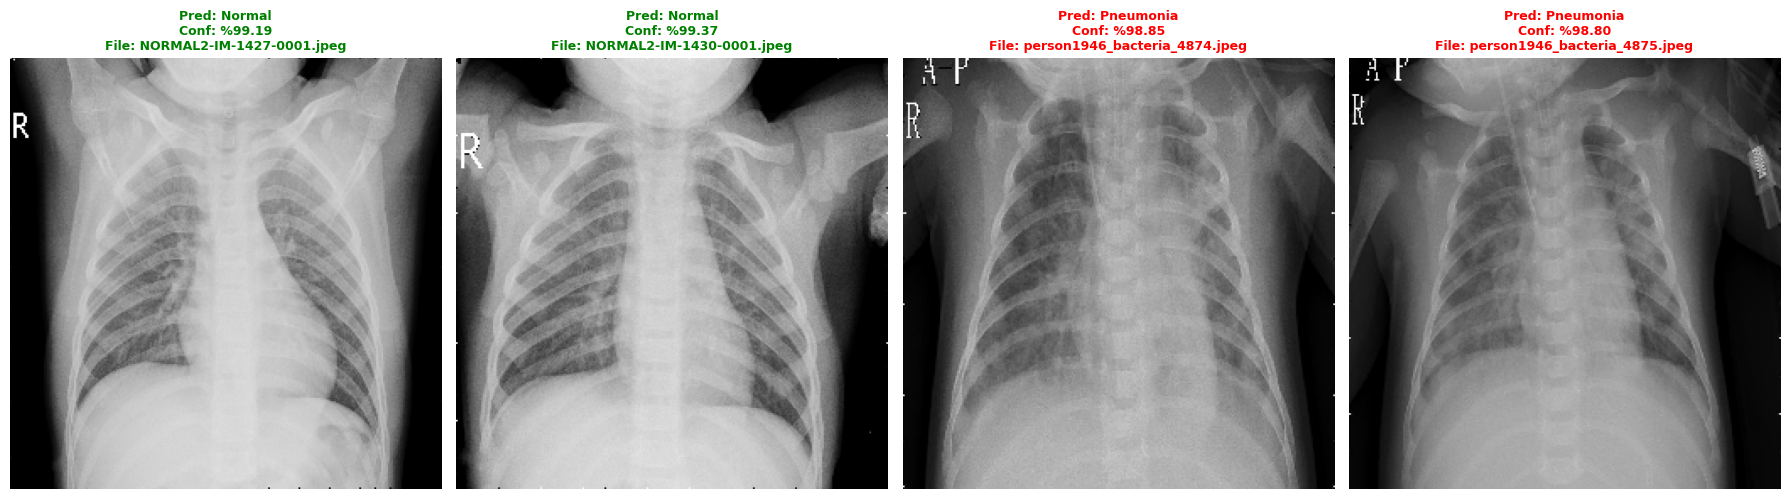

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# --- 1. AYARLAR ---
folder_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Pneumonia\TEST"
model_path = r"C:\Users\batuh\OneDrive\Desktop\Mediain-New-Models\Pneumonia\Unet-Pneumonia.h5"
model = tf.keras.models.load_model(model_path)

target_size = (256, 256)
# Sözlüğü modelinizin eğitim sırasına göre kontrol edin. 
# Genelde 0: Normal, 1: Pneumonia olur. Görsele göre yer değiştirebilirsiniz.
class_labels = {0: 'Normal', 1: 'Pneumonia'} 

all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
selected_images = all_images[:4] 

# --- 2. TAHMİN VE GÖRSELLEŞTİRME ---
plt.figure(figsize=(18, 5))

for i, img_name in enumerate(selected_images):
    img_path = os.path.join(folder_path, img_name)
    
    # Görüntü hazırlama
    img = image.load_img(img_path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_batch = np.expand_dims(img_array / 255.0, axis=0)

    # Tahmin Mantığı
    preds = model.predict(img_batch, verbose=0)
    
    # Çıktı katmanı 1 nöron ise (Sigmoid)
    if preds.shape[1] == 1:
        prob = preds[0][0]
        # 0.5 eşik değerine göre sınıf belirleme
        class_idx = 1 if prob > 0.5 else 0
        confidence = prob * 100 if class_idx == 1 else (1 - prob) * 100
    # Çıktı katmanı 2 nöron ise (Softmax)
    else:
        class_idx = np.argmax(preds[0])
        confidence = preds[0][class_idx] * 100

    predicted_label = class_labels.get(class_idx, "Unknown")
    
    # Görselleştirme
    plt.subplot(1, 4, i + 1)
    plt.imshow(img_array.astype('uint8'))
    plt.axis('off')
    
    # Başlık rengini tahmine göre ayarla (Örn: Pneumonia ise Kırmızı, Normal ise Yeşil)
    title_color = 'red' if predicted_label == 'Pneumonia' else 'green'
    
    plt.title(f"Pred: {predicted_label}\nConf: %{confidence:.2f}\nFile: {img_name}", 
              fontsize=9, color=title_color, fontweight='bold')

plt.tight_layout()
plt.show()